# Donghang Zou's UChicago ADS Code Sample

In [1]:
# GitHub: https://github.com/Booth-DH/Global_AI_Internship

### 1. Motivation and data

This sample is an excerpt from my Global AI internship project; the full code and analysis are available at the GitHub link above. Chronic disease burden varies across U.S. counties, and its social correlates can guide public health resources. The project joins CDC PLACES 2021 to 2025 with CDC SVI 2020 and 2022 in a county panel, compares diabetes and hypertension correlates, and maps K-means profiles. Food, housing, and transportation insecurity are the strongest diabetes correlates (r of 0.937, 0.921, and 0.914).

### 2. Setup and loading the data

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch, Patch
from matplotlib.path import Path as MplPath
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

ROOT = Path.cwd().parent if Path.cwd().name == 'code_sample' else Path.cwd()
RAW, OUT = ROOT / 'data/raw', ROOT / 'code_sample'
outcomes = ['DIABETES', 'BPHIGH']
factor_labels = {'LPA': 'Inactivity', 'OBESITY': 'Obesity', 'CSMOKING': 'Smoking', 'ACCESS2': 'Uninsured',
    'DEPRESSION': 'Depression', 'SLEEP': 'Short sleep', 'BINGE': 'Binge drinking', 'RPL_THEMES': 'Overall SVI',
    'RPL_THEME1': 'SVI: socioeconomic', 'RPL_THEME2': 'SVI: household', 'RPL_THEME3': 'SVI: minority',
    'RPL_THEME4': 'SVI: housing/transport', 'FOODINSECU': 'Food insecurity', 'HOUSINSECU': 'Housing insecurity',
    'LACKTRPT': 'Transport barriers', 'LONELINESS': 'Loneliness'}
factors = list(factor_labels)
svi_cols = [factor for factor in factors if factor.startswith('RPL')]
# String identifiers preserve leading zeros.
places = pd.read_csv(RAW / 'places_county_2025.csv', low_memory=False,
    dtype={'locationid': 'string', 'year': 'int16', 'data_value': 'float64'})
svi = pd.read_csv(RAW / 'svi_county_2022.csv', dtype={'FIPS': 'string'}, usecols=['FIPS', *svi_cols])
print(f'locationid: {places.locationid.dtype}; FIPS: {svi.FIPS.dtype}; data_value: {places.data_value.dtype}')

Matplotlib is building the font cache; this may take a moment.


locationid: string; FIPS: string; data_value: float64


### 3. Building the county snapshot



In [3]:
def prepare_county_snapshot(places, svi):
    health = places.loc[places.stateabbr.ne('US') & places.data_value_type.eq('Age-adjusted prevalence')].copy()
    health['FIPS'] = health.locationid.str.zfill(5)
    health = health.sort_values('year').drop_duplicates(['FIPS', 'measureid'], keep='last')
    wide = health.pivot(index='FIPS', columns='measureid', values='data_value')
    # Treat -999 as missing.
    svi = svi.assign(FIPS=svi.FIPS.str.zfill(5)).replace(-999, np.nan).set_index('FIPS')
    # Validation raises an error for duplicate county identifiers.
    return wide.join(svi, validate='one_to_one').dropna(subset=[*outcomes, 'RPL_THEMES'])
counties = prepare_county_snapshot(places, svi)

### 4. Measuring associations

Pairwise r uses every available county; the common sample holds counties fixed across factors.

In [4]:
def compare_correlations(data, outcome, factors, sample_policy='pairwise'):
    values = data[[outcome, *factors]].dropna(subset=[outcome])
    if sample_policy == 'common':
        values = values.dropna()
    return pd.DataFrame({'r': values[factors].corrwith(values[outcome]), 'n': values[factors].count()})
results = {outcome: compare_correlations(counties, outcome, factors) for outcome in outcomes}
correlations = pd.DataFrame({outcome: result.r for outcome, result in results.items()})
shown = ['FOODINSECU', 'HOUSINSECU', 'LACKTRPT', 'LPA']
common = compare_correlations(counties, 'DIABETES', factors, 'common')
comparison = results['DIABETES'].join(common, lsuffix='_pair', rsuffix='_common').loc[shown]
print(comparison.round(3).rename_axis(None))

            r_pair  n_pair  r_common  n_common
FOODINSECU   0.937    2299     0.937      2299
HOUSINSECU   0.921    2299     0.921      2299
LACKTRPT     0.914    2299     0.914      2299
LPA          0.873    2956     0.850      2299


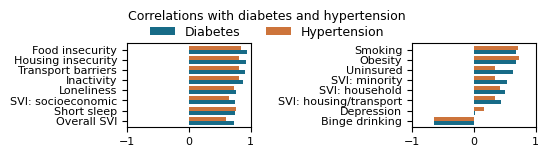

In [5]:
def plot_correlations(correlations):
    ranked = correlations.sort_values('DIABETES', ascending=False).rename(index=factor_labels)
    fig, axes = plt.subplots(1, 2, figsize=(5.6, 1.45))
    for ax, start in zip(axes, [0, 8]):
        ranked.iloc[start:start + 8].iloc[::-1].plot.barh(ax=ax, width=.8,
            color=['#176b87', '#cd743b'], legend=False, fontsize=8)
        ax.set(xlim=(-1, 1), xticks=[-1, 0, 1], xlabel='', ylabel='')
    fig.suptitle('Correlations with diabetes and hypertension', fontsize=9)
    fig.legend(axes[0].containers, ['Diabetes', 'Hypertension'], loc='upper center',
        bbox_to_anchor=(.5, .95), ncol=2, frameon=False, fontsize=9)
    fig.subplots_adjust(left=.25, right=.98, bottom=.17, top=.75, wspace=1.3)
    return fig
figure = plot_correlations(correlations)
figure.savefig(OUT / 'figures/fig_correlations.png', dpi=240)
plt.show()

### 5. Grouping and mapping counties

K-means groups counties with similar standardized profiles; the table shows unweighted county means (prevalence %, SVI rank).

In [6]:
strength = correlations.abs().mean(axis=1).sort_values(ascending=False)
features = outcomes + strength[strength >= .40].index.tolist()
complete = counties.dropna(subset=features).copy()
# Standardize so measurement units do not drive distances.
scaled = StandardScaler().fit_transform(complete[features])
model = KMeans(n_clusters=4, random_state=42, n_init=10).fit(scaled)
anchors = [features.index(factor) for factor in [*outcomes, 'RPL_THEMES']]
# Order tiers by mean standardized diabetes, hypertension, and SVI.
order = np.argsort(model.cluster_centers_[:, anchors].mean(axis=1))
tiers = ['Low', 'Moderate', 'High', 'Highest']
labels = pd.Series(model.labels_, index=complete.index).map(dict(zip(order, tiers)))
complete['tier'] = pd.Categorical(labels, categories=tiers, ordered=True)
summary = complete.groupby('tier', observed=True).agg(counties=('DIABETES', 'size'),
    diabetes=('DIABETES', 'mean'), hypertension=('BPHIGH', 'mean'), SVI=('RPL_THEMES', 'mean'))
print(f'{len(complete):,} clustered counties; silhouette = {silhouette_score(scaled, model.labels_):.3f}')
print(summary.round(3).rename_axis(None).to_string())

2,299 clustered counties; silhouette = 0.203
          counties  diabetes  hypertension    SVI
Low            765     9.090        29.758  0.190
Moderate       788    10.765        33.306  0.456
High           508    12.555        36.755  0.754
Highest        238    15.786        42.943  0.895


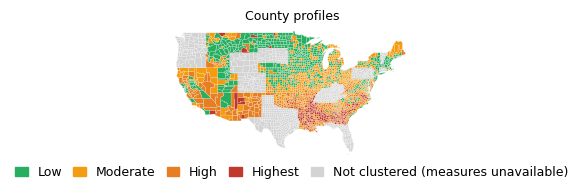

In [7]:
def plot_county_profiles(complete):
    colors = dict(zip([*tiers, 'Not clustered'], ['#27ae60', '#f39c12', '#e67e22', '#c0392b', '#d3d3d3']))
    lookup = complete.tier.astype('string').map(colors).to_dict()
    geo = json.loads((ROOT / 'data/processed/us_counties.geojson').read_text())
    fig, ax = plt.subplots(figsize=(5.6, 1.8))
    ax.axis('off')
    visible = [county for county in geo['features'] if county['id'][:2] not in {'02', '15', '72'}]
    for county in visible:
        fips, geometry = county['id'], county['geometry']
        polygons = [geometry['coordinates']] if geometry['type'] == 'Polygon' else geometry['coordinates']
        for polygon in polygons:
            shape = MplPath.make_compound_path(*[MplPath(ring, closed=True) for ring in polygon])
            ax.add_patch(PathPatch(shape, facecolor=lookup.get(fips, '#d3d3d3'), edgecolor='w', lw=.12))
    ax.set(xlim=(-125, -66), ylim=(24, 50), aspect=1.25)
    ax.set_title('County profiles', fontsize=9)
    colors['Not clustered (measures unavailable)'] = colors.pop('Not clustered')
    handles = [Patch(color=color, label=tier) for tier, color in colors.items()]
    fig.legend(handles=handles, loc='lower center', ncol=5, frameon=False,
        columnspacing=.9, handlelength=1, fontsize=9)
    fig.subplots_adjust(left=.02, right=.98, top=.88, bottom=.16)
    return fig
figure = plot_county_profiles(complete)
figure.savefig(OUT / 'figures/fig_risk_tier_map.png', dpi=240)
plt.show()

Grey marks nine states without social-needs measures (CO, FL, OR, SD, TN, TX, VT, WA, WY), KY and PA without diabetes or hypertension estimates, and nine CT planning regions without cached geometry.

### 6. Findings and limits

On the same 2,299 counties, social-needs factors stay the strongest diabetes correlates while inactivity weakens, and higher-burden profiles cluster in the Deep South. These patterns could help prioritize county follow-up, but they are descriptive, not causal: PLACES values are model-based estimates with shared demographic inputs that can inflate correlations, measurement years differ, and profiles overlap.